In [27]:
import torch
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [28]:
traindata=datasets.FashionMNIST(root='data',
                                train=True,
                                download=False,
                                transform=ToTensor(),
                                target_transform=None)
testdata=datasets.FashionMNIST(root='data',
                               train=False,
                               download=False,
                               transform=ToTensor(),
                               target_transform=None)


In [29]:
from torch.utils.data import DataLoader

In [30]:
train_dataloader=DataLoader(dataset=traindata,
                            batch_size=32)
test_dataloader=DataLoader(dataset=testdata,
                           batch_size=32)

In [31]:
img=next(iter(train_dataloader))

In [32]:
img[0][0].shape
image,label=img
image
label

tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1, 4, 8,
        4, 3, 0, 2, 4, 4, 5, 3])

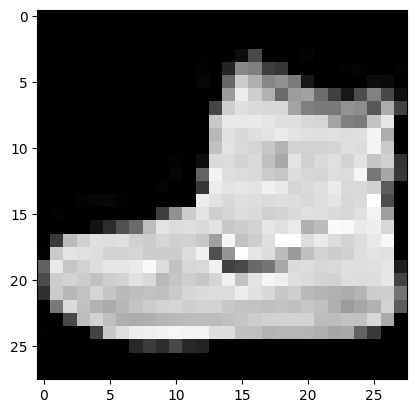

In [33]:
plt.imshow(image[0].squeeze(),cmap='gray')

In [34]:
from torch import nn

class convolutional(nn.Module):
    def __init__(self,inp,hidden,output):
        super().__init__()
        self.layers=nn.Sequential(
                                    nn.Conv2d(in_channels=inp,out_channels=hidden,
                                             kernel_size=3,
                                             padding=1,
                                             stride=1),
                                    nn.ReLU(),
                                    nn.Conv2d(in_channels=hidden,
                                              out_channels=hidden,
                                              kernel_size=3,
                                              padding=1,
                                              stride=1),
                                    nn.ReLU(),

                                    nn.MaxPool2d(kernel_size=2),


                                    nn.Conv2d(in_channels=hidden,out_channels=hidden,
                                             kernel_size=3,
                                             padding=1,
                                             stride=1),
                                    nn.ReLU(),
                                    nn.Conv2d(in_channels=hidden,
                                              out_channels=hidden,
                                              kernel_size=3,
                                              padding=1,
                                              stride=1),
                                    nn.ReLU(),

                                    nn.MaxPool2d(kernel_size=2)
        )
        self.classifier=nn.Sequential(
                                        nn.Flatten(),
                                        nn.Linear(in_features=hidden*7*7,out_features=output)
        )


    def forward(self,x):
        return self.classifier(self.layers(x))

                                    
                                

In [35]:
model_0=convolutional(1,10,10).to('mps')

In [36]:
model_0.state_dict()

OrderedDict([('layers.0.weight',
              tensor([[[[ 0.2980, -0.1651, -0.1536],
                        [ 0.0539, -0.2625,  0.1244],
                        [ 0.0311, -0.1500,  0.1290]]],
              
              
                      [[[ 0.0175, -0.2821,  0.0263],
                        [ 0.2339,  0.3065,  0.1304],
                        [-0.3222,  0.1602,  0.1127]]],
              
              
                      [[[-0.0244,  0.1304, -0.0088],
                        [ 0.2100, -0.0445, -0.0671],
                        [ 0.1297,  0.0162, -0.0065]]],
              
              
                      [[[-0.1351, -0.1404,  0.2505],
                        [-0.1525,  0.0540,  0.0364],
                        [-0.2060,  0.1675,  0.2006]]],
              
              
                      [[[-0.0339,  0.1897,  0.0396],
                        [-0.1267, -0.2075,  0.1539],
                        [-0.3003,  0.2084,  0.3173]]],
              
              
            

In [37]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.001)

In [38]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [39]:
traindata


Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [40]:
train_dataloader

In [41]:
def accuracy(y_true,y_pred):
    print(y_true.shape,y_pred.shape)
    correct=torch.eq(y_pred,y_true).sum().item()
    return (correct/len(y_true))*100

In [42]:
epoch=10
from tqdm.auto import tqdm
for i in tqdm(range(epoch)):

    model_0.train()
    for batch,(x,y) in enumerate(train_dataloader):
        x=x.to('mps')
        y=y.to('mps')
        y_pred=model_0(x)
       
        
        loss=loss_fn(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if(batch%400==0):
            print(loss,batch)
            print(accuracy(y,y_pred.argmax(dim=1)))
        

  0%|          | 0/10 [00:00<?, ?it/s]

tensor(2.3032, device='mps:0', grad_fn=<NllLossBackward0>) 0
torch.Size([32]) torch.Size([32])
15.625
tensor(0.4716, device='mps:0', grad_fn=<NllLossBackward0>) 400
torch.Size([32]) torch.Size([32])
81.25
tensor(0.5445, device='mps:0', grad_fn=<NllLossBackward0>) 800
torch.Size([32]) torch.Size([32])
75.0
tensor(0.4236, device='mps:0', grad_fn=<NllLossBackward0>) 1200
torch.Size([32]) torch.Size([32])
84.375
tensor(0.3882, device='mps:0', grad_fn=<NllLossBackward0>) 1600
torch.Size([32]) torch.Size([32])
84.375
tensor(0.3100, device='mps:0', grad_fn=<NllLossBackward0>) 0
torch.Size([32]) torch.Size([32])
87.5
tensor(0.2226, device='mps:0', grad_fn=<NllLossBackward0>) 400
torch.Size([32]) torch.Size([32])
93.75
tensor(0.4913, device='mps:0', grad_fn=<NllLossBackward0>) 800
torch.Size([32]) torch.Size([32])
81.25
tensor(0.2658, device='mps:0', grad_fn=<NllLossBackward0>) 1200
torch.Size([32]) torch.Size([32])
90.625
tensor(0.2605, device='mps:0', grad_fn=<NllLossBackward0>) 1600
torch.Si

In [43]:
model_0

convolutional(
  (layers): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)